# **Sistema de Extracción de Respuestas en el Dominio Médico (Casimedicos-QA)**
---

In [ ]:
# librerías
!pip install --upgrade datasets dill transformers evaluate accelerate
!pip install matplotlib seaborn pandas gradio

In [ ]:
#Montar Google Drive e importar TODAS las librerías del proyecto
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import time
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from huggingface_hub import hf_hub_download, HfApi
from transformers import (
    AutoTokenizer, AutoModelForQuestionAnswering,
    TrainingArguments, Trainer, DefaultDataCollator, pipeline
)
import evaluate
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Librerías cargadas correctamente.


---
## **FASE 1: PREPARACIÓN Y ANÁLISIS EXPLORATORIO DE DATOS**
Cargamos y exploramos los datasets que vamos a utilizar.

In [ ]:
# Carga, aplanado y limpieza del dataset Casimedicos-SQuAD
print("1. Conectando con Hugging Face para buscar archivos...")
api = HfApi()
archivos = api.list_repo_files("HiTZ/casimedicos-squad", repo_type="dataset")
archivos_json = [f for f in archivos if f.endswith('.json')]
print(f"Archivos JSON detectados: {archivos_json}")

def procesar_json_squad(repo_id, filename):
    ruta_local = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")
    with open(ruta_local, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if "data" in data:
        data = data["data"]
    registros = []
    for articulo in data:
        titulo = articulo.get("title", "")
        for parrafo in articulo.get("paragraphs", []):
            contexto = parrafo.get("context", "")
            for qa in parrafo.get("qas", []):
                pregunta   = qa.get("question", "")
                id_qa      = str(qa.get("id", ""))
                resp_raw   = qa.get("answers", [])
                imposible  = qa.get("is_impossible", False)
                textos     = [a["text"] for a in resp_raw]
                inicios    = [a["answer_start"] for a in resp_raw]
                registros.append({
                    "id": id_qa, "title": titulo, "context": contexto,
                    "question": pregunta,
                    "answers": {"text": textos, "answer_start": inicios},
                    "is_impossible": imposible
                })
    return Dataset.from_pandas(pd.DataFrame(registros))

diccionario_datasets = {}
for archivo in archivos_json:
    if "dev" in archivo.lower() or "val" in archivo.lower():
        split = "validation"
    elif "test" in archivo.lower():
        split = "test"
    else:
        split = "train"
    print(f"2. Procesando '{archivo}' como split '{split}'...")
    diccionario_datasets[split] = procesar_json_squad("HiTZ/casimedicos-squad", archivo)

casimedicos = DatasetDict(diccionario_datasets)
print("\n--- Dataset estructurado con éxito ---")
print(casimedicos)
ej = casimedicos['train'][0]
print(f"\nEjemplo -> Pregunta: {ej['question']}")
print(f"Contexto (snippet): {ej['context'][:200]}...")
print(f"Respuesta: {ej['answers']}")

1. Conectando con Hugging Face para buscar archivos...
Archivos JSON detectados: ['data/es/es_dev_casimedicos_squad.json', 'data/es/es_test_casimedicos_squad.json', 'data/es/es_train_casimedicos_squad.json']
2. Procesando 'data/es/es_dev_casimedicos_squad.json' como split 'validation'...
2. Procesando 'data/es/es_test_casimedicos_squad.json' como split 'test'...
2. Procesando 'data/es/es_train_casimedicos_squad.json' como split 'train'...

--- Dataset estructurado con éxito ---
DatasetDict({
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'is_impossible'],
        num_rows: 56
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'is_impossible'],
        num_rows: 119
    })
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'is_impossible'],
        num_rows: 404
    })
})

Ejemplo -> Pregunta: Juan, residente de segundo año, atiende en urgencias a Sofia, una m

--- Estadísticas descriptivas ---
       context_len  question_len  answer_len
count       404.00        404.00      404.00
mean         87.49         66.45       31.57
std          75.48         28.08       20.63
min           3.00         20.00        3.00
25%          38.00         46.00       19.00
50%          66.50         62.00       27.00
75%         110.00         83.00       39.25
max         502.00        194.00      283.00


/tmp/ipykernel_3836/2410823718.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='is_impossible', palette='pastel', ax=axes[1])
/tmp/ipykernel_3836/2410823718.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Con Respuesta', 'Sin Respuesta'])


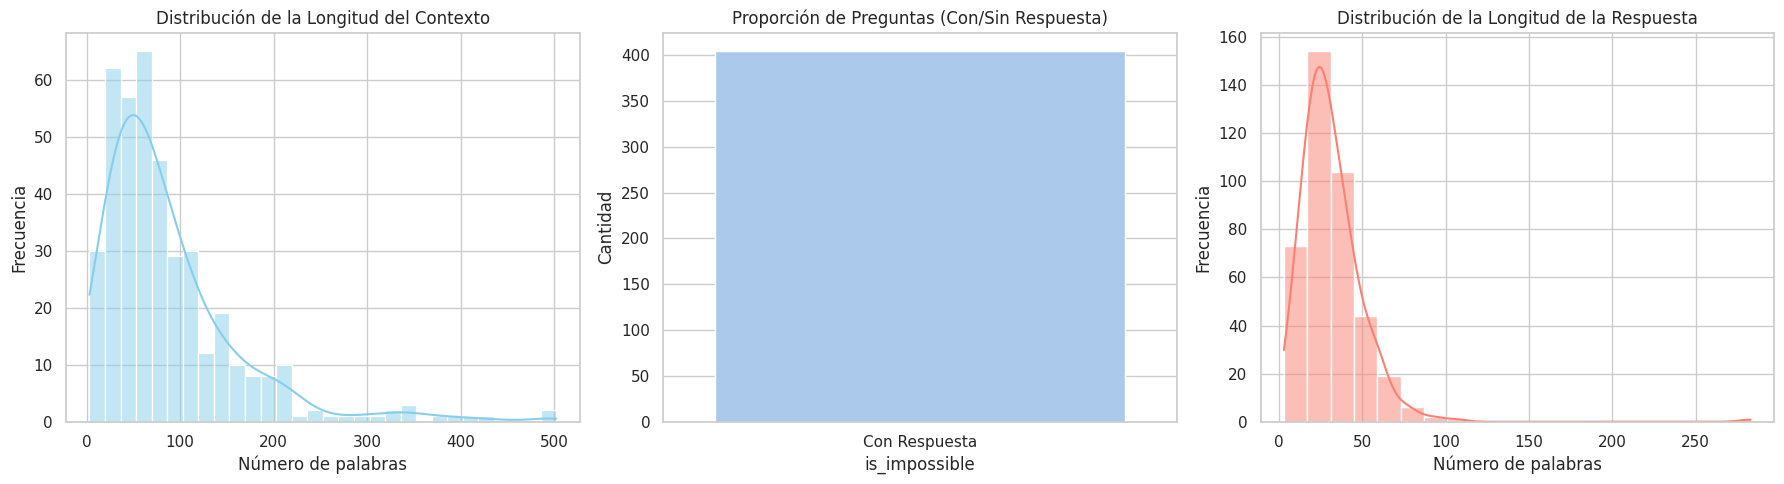

Gráfico guardado como 'eda_casimedicos.png'


In [ ]:
# Análisis Exploratorio de Datos (EDA)
df_train = casimedicos['train'].to_pandas()

df_train['context_len']  = df_train['context'].apply(lambda x: len(x.split()))
df_train['question_len'] = df_train['question'].apply(lambda x: len(x.split()))
df_train['answer_len']   = df_train['answers'].apply(
    lambda x: len(x['text'][0].split()) if x['text'] else 0
)

print("--- Estadísticas descriptivas ---")
print(df_train[['context_len', 'question_len', 'answer_len']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_train['context_len'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de la Longitud del Contexto')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')

sns.countplot(data=df_train, x='is_impossible', palette='pastel', ax=axes[1])
axes[1].set_title('Proporción de Preguntas (Con/Sin Respuesta)')
axes[1].set_xticklabels(['Con Respuesta', 'Sin Respuesta'])
axes[1].set_ylabel('Cantidad')

sns.histplot(df_train['answer_len'][df_train['answer_len'] > 0],
             bins=20, kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Distribución de la Longitud de la Respuesta')
axes[2].set_xlabel('Número de palabras')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_casimedicos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'eda_casimedicos.png'")

In [ ]:
# Carga y estandarización de emrQA
print("Cargando emrQA-msquad")
dataset_medico_base = load_dataset("Eladio/emrqa-msquad")

def limpiar_emrqa(example, idx):
    if isinstance(example["answers"], dict):
        textos  = example["answers"].get("text", [])
        inicios = example["answers"].get("answer_start", [])
    else:
        textos, inicios = [], []
    return {
        "id": f"emrqa_{idx}",
        "title": "medical_record",
        "context": example["context"],
        "question": example["question"],
        "answers": {
            "text":         [textos[0]]  if textos  else [],
            "answer_start": [inicios[0]] if inicios else []
        },
        "is_impossible": False
    }

print("Estandarizando formato emrQA")
emrqa_limpio = dataset_medico_base.map(
    limpiar_emrqa,
    with_indices=True,
    remove_columns=dataset_medico_base['train'].column_names
)
print("emrQA listo.")
print(f"Ejemplo de pregunta emrQA: {emrqa_limpio['train'][0]['question']}")

Cargando emrQA-msquad...


README.md:   0%|          | 0.00/670 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130956 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/32739 [00:00<?, ? examples/s]

Estandarizando formato emrQA...


Map:   0%|          | 0/130956 [00:00<?, ? examples/s]

Map:   0%|          | 0/32739 [00:00<?, ? examples/s]

emrQA listo.
Ejemplo de pregunta emrQA: What is her current dose of lasix ( furosemide )


---
## **FASE 2: TOKENIZACIÓN Y MODELADO**
Voy a usar **mBERT** (`bert-base-multilingual-cased`): modelo BERT entrenado en 104 idiomas porque los datos son multilingues.

Aplico **ventanas deslizantes** (*sliding window*) para manejar los textos médicos largos
que superan el límite de 384 tokens.

In [ ]:
#Cargar del tokenizador mBERT y definición de la función de preprocesamiento
MODEL_CHECKPOINT = "bert-base-multilingual-cased"
print(f"Cargando tokenizador: {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

MAX_LENGTH = 384   # Longitud máxima de tokens por ventana
DOC_STRIDE = 128   # Solapamiento entre ventanas deslizantes consecutivas

def preparar_caracteristicas_entrenamiento(examples):
    # Recortamos preguntas muy largas (max 60 palabras) para dejar espacio al contexto
    examples["question"] = [" ".join(q.split()[:60]) for q in examples["question"]]

    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=MAX_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_examples.pop("offset_mapping")

    start_positions = []
    end_positions   = []

    for i, offsets in enumerate(offset_mapping):
        input_ids   = tokenized_examples["input_ids"][i]
        cls_index   = input_ids.index(tokenizer.cls_token_id)
        sequence_ids = tokenized_examples.sequence_ids(i)
        sample_index = sample_mapping[i]
        answers      = examples["answers"][sample_index]

        # Si el contexto fue completamente truncado, apuntar a [CLS]
        if 1 not in sequence_ids:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
            continue

        # Si no hay respuesta (is_impossible), apuntar a [CLS]
        if len(answers["answer_start"]) == 0:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            start_char = answers["answer_start"][0]
            end_char   = start_char + len(answers["text"][0])

            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1
            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            # Si la respuesta queda fuera de esta ventana, apuntamos a [CLS]
            if not (offsets[token_start_index][0] <= start_char
                    and offsets[token_end_index][1] >= end_char):
                start_positions.append(cls_index)
                end_positions.append(cls_index)
            else:
                while token_start_index < len(offsets) and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                start_positions.append(token_start_index - 1)
                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                end_positions.append(token_end_index + 1)

    tokenized_examples["start_positions"] = start_positions
    tokenized_examples["end_positions"]   = end_positions
    return tokenized_examples

print("Función de preprocesamiento lista.")

Cargando tokenizador: bert-base-multilingual-cased...
Función de preprocesamiento lista.


In [ ]:
# Aplicar la tokenización a todos los datasets
print("Tokenizando Casimedicos...")
tokenized_casimedicos = casimedicos.map(
    preparar_caracteristicas_entrenamiento,
    batched=True,
    remove_columns=casimedicos["train"].column_names
)

print("\nTokenizando emrQA (puede tardar unos minutos)...")
tokenized_emrqa = emrqa_limpio.map(
    preparar_caracteristicas_entrenamiento,
    batched=True,
    remove_columns=emrqa_limpio["train"].column_names
)

print("\n--- Tokenización completada ---")
print(f"Casimedicos train: {len(casimedicos['train'])} ejemplos -> {len(tokenized_casimedicos['train'])} fragmentos")
print(f"emrQA train:       {len(emrqa_limpio['train'])} ejemplos -> {len(tokenized_emrqa['train'])} fragmentos")
print("(Los fragmentos son más porque los textos largos se dividen en ventanas con solapamiento.)")

Tokenizando Casimedicos...


Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Map:   0%|          | 0/119 [00:00<?, ? examples/s]

Map:   0%|          | 0/404 [00:00<?, ? examples/s]


Tokenizando emrQA (puede tardar unos minutos)...


NameError: name 'emrqa_limpio' is not defined

---
## **FASE 3: DISEÑO EXPERIMENTAL Y FINE-TUNING**

Realizamos cuatro experimentos para comparar el efecto del dominio y del volumen de datos:

| Experimento | Datos de entrenamiento | Objetivo |
|---|---|---|
| **Baseline** | SQuAD v2 (inglés genérico, ~10k) | Transferencia cross-lingual sin dominio médico |
| **Exp. 1** | Casimedicos solo (~400 ejs.) | Rendimiento con pocos datos del dominio objetivo |
| **Exp. 2** | emrQA + Casimedicos combinados | Mejora con más datos médicos (multi-idioma) |
| **Exp. 3** | emrQA → Casimedicos (secuencial) | Ventaja del *domain adaptation* progresivo |

### Baseline: Entrenamiento en SQuAD Genérico (`squad_v2`)
Fine-tuning de mBERT en SQuAD v2 (inglés). Sirve de referencia para medir cuánto aporta la especialización médica.

In [ ]:
# Baseline - Entrenamiento en SQuAD v2 (dominio genérico, inglés)
print("1. Cargando SQuAD v2...")
squad_v2 = load_dataset("squad_v2")

print("2. Tokenizando SQuAD v2...")
tokenized_squad = squad_v2.map(
    preparar_caracteristicas_entrenamiento,
    batched=True,
    remove_columns=squad_v2["train"].column_names
)

# Muestra reducida para no agotar el tiempo de Colab
small_train = tokenized_squad["train"].shuffle(seed=42).select(range(10000))
small_eval  = tokenized_squad["validation"].shuffle(seed=42).select(range(2000))

print("3. Cargando mBERT en estado inicial (sin fine-tuning)...")
modelo_baseline = AutoModelForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT)

args_baseline = TrainingArguments(
    output_dir="./resultados_baseline_squad",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

trainer_baseline = Trainer(
    model=modelo_baseline,
    args=args_baseline,
    train_dataset=small_train,
    eval_dataset=small_eval,
    data_collator=DefaultDataCollator(),
)

print("4. Iniciando entrenamiento del Baseline SQuAD...")
inicio = time.time()
trainer_baseline.train()
fin = time.time()
print(f"--- Entrenamiento completado en {(fin - inicio)/60:.2f} minutos ---")

ruta_baseline = "./modelo_baseline_squad"
trainer_baseline.save_model(ruta_baseline)
tokenizer.save_pretrained(ruta_baseline)
print(f"Modelo baseline guardado en: {ruta_baseline}")

1. Cargando SQuAD v2...
2. Tokenizando SQuAD v2...
3. Cargando mBERT en estado inicial (sin fine-tuning)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

4. Iniciando entrenamiento del Baseline SQuAD...


Epoch,Training Loss,Validation Loss
1,2.065524,1.351101
2,1.296749,1.312402


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

--- Entrenamiento completado en 32.04 minutos ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo baseline guardado en: ./modelo_baseline_squad


In [ ]:
# Evaluación del Baseline en Casimedicos (validación)
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

squad_metric = evaluate.load("squad")

modelo_eval_b    = AutoModelForQuestionAnswering.from_pretrained("./modelo_baseline_squad")
tokenizer_eval_b = AutoTokenizer.from_pretrained("./modelo_baseline_squad")
modelo_eval_b.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_eval_b.to(device)

def predecir_respuesta(pregunta, contexto, modelo, tok):
    inputs = tok(
        pregunta[:300], contexto,
        truncation="only_second", max_length=MAX_LENGTH, stride=DOC_STRIDE,
        return_overflowing_tokens=True, return_offsets_mapping=True,
        padding="max_length", return_tensors="pt"
    )
    offset_mapping = inputs.pop("offset_mapping")
    inputs.pop("overflow_to_sample_mapping", None)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = modelo(**inputs)
    mejor_texto, mejor_score = "", -float("inf")
    for i in range(outputs.start_logits.shape[0]):
        sl = outputs.start_logits[i].cpu()
        el = outputs.end_logits[i].cpu()
        offsets = offset_mapping[i]
        for start in range(len(sl)):
            for end in range(start, min(start + 150, len(el))):  # ← 30 → 150
                score = sl[start] + el[end]
                if score > mejor_score:
                    mejor_score = score
                    if start == 0:
                        mejor_texto = ""
                    elif offsets[start][0] is not None and offsets[end][1] is not None:
                        mejor_texto = contexto[offsets[start][0]: offsets[end][1]]
    return mejor_texto

referencias_b, predicciones_b = [], []
print("Evaluando baseline en Casimedicos...")
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_b.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_b, tokenizer_eval_b)
    except Exception:
        texto_pred = ""
    predicciones_b.append({"id": str(ejemplo["id"]), "prediction_text": texto_pred})

resultados_baseline = squad_metric.compute(predictions=predicciones_b, references=referencias_b)
print("\n" + "="*55)
print("RESULTADOS BASELINE (SQuAD Genérico -> Casimedicos)")
print("="*55)
print(f"Exact Match (EM): {resultados_baseline['exact_match']:.2f} %")
print(f"F1-Score:         {resultados_baseline['f1']:.2f} %")
print("="*55)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluando baseline en Casimedicos...


  0%|          | 0/56 [00:00<?, ?it/s]


RESULTADOS BASELINE (SQuAD Genérico -> Casimedicos)
Exact Match (EM): 0.00 %
F1-Score:         1.75 %


### Experimento 1: Fine-Tuning Solo con Casimedicos
Fine-tuning directo con los ~400 ejemplos del dominio objetivo.
Mide el rendimiento cuando solo disponemos de datos especializados (pero pocos).

In [ ]:
# Experimento 1 - Configuración del Trainer (Casimedicos Puro)
print("Cargando mBERT en estado inicial para el Experimento 1...")
modelo_exp1 = AutoModelForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT)

args_exp1 = TrainingArguments(
    output_dir="./resultados_casimedicos_puro",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
)

trainer_exp1 = Trainer(
    model=modelo_exp1,
    args=args_exp1,
    train_dataset=tokenized_casimedicos["train"],
    eval_dataset=tokenized_casimedicos["validation"],
    data_collator=DefaultDataCollator(),
)
print("Trainer del Experimento 1 listo.")

Cargando mBERT en estado inicial para el Experimento 1...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Trainer del Experimento 1 listo.


In [ ]:
# Experimento 1 - Entrenamiento
print("Iniciando Experimento 1: Fine-Tuning SOLO sobre Casimedicos...")
inicio = time.time()
trainer_exp1.train()
fin = time.time()
print(f"--- Entrenamiento completado en {(fin - inicio)/60:.2f} minutos ---")

ruta_exp1 = "./modelo_final_casimedicos_puro"
trainer_exp1.save_model(ruta_exp1)
tokenizer.save_pretrained(ruta_exp1)
print(f"Modelo guardado en: {ruta_exp1}")

Iniciando Experimento 1: Fine-Tuning SOLO sobre Casimedicos...


Epoch,Training Loss,Validation Loss
1,1.878485,1.844723
2,1.463156,1.782459
3,1.314901,1.731773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

--- Entrenamiento completado en 3.68 minutos ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./modelo_final_casimedicos_puro


In [ ]:
# Evaluación del Experimento 1 (Exact Match y F1-Score)
squad_metric = evaluate.load("squad")

modelo_eval_1    = AutoModelForQuestionAnswering.from_pretrained("./modelo_final_casimedicos_puro")
tokenizer_eval_1 = AutoTokenizer.from_pretrained("./modelo_final_casimedicos_puro")
modelo_eval_1.eval()
modelo_eval_1.to(device)

referencias_1, predicciones_1 = [], []
print("Evaluando Experimento 1 en Casimedicos (validación)...")
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_1.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_1, tokenizer_eval_1)
    except Exception:
        texto_pred = ""
    predicciones_1.append({"id": str(ejemplo["id"]), "prediction_text": texto_pred})

resultados_exp1 = squad_metric.compute(predictions=predicciones_1, references=referencias_1)
print("\n" + "="*55)
print("RESULTADOS EXPERIMENTO 1 (Casimedicos Puro)")
print("="*55)
print(f"Exact Match (EM): {resultados_exp1['exact_match']:.2f} %")
print(f"F1-Score:         {resultados_exp1['f1']:.2f} %")
print("="*55)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluando Experimento 1 en Casimedicos (validación)...


  0%|          | 0/56 [00:00<?, ?it/s]


RESULTADOS EXPERIMENTO 1 (Casimedicos Puro)
Exact Match (EM): 0.00 %
F1-Score:         3.88 %


---
## **FASE FINAL: EXPERIMENTOS CON TRANSFER LEARNING**

### Experimento 2: Entrenamiento Combinado (emrQA + Casimedicos)
Entrenamos mBERT con datos médicos en inglés (emrQA) y español (Casimedicos) mezclados.
Comprobamos si más datos médicos (aunque sean de otro idioma) mejoran el rendimiento.

In [ ]:
# Experimento 2 - Entrenamiento Combinado (emrQA + Casimedicos)
print("1. Creando el dataset mixto (emrQA + Casimedicos)...")
emrqa_sample = tokenized_emrqa["train"].shuffle(seed=42).select(range(15000))
train_mixto  = concatenate_datasets([emrqa_sample, tokenized_casimedicos["train"]])
train_mixto  = train_mixto.shuffle(seed=42)
print(f"Dataset mixto: {len(train_mixto)} ejemplos totales")

print("\n2. Cargando mBERT en estado inicial para el Experimento 2...")
modelo_exp2 = AutoModelForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT)

args_exp2 = TrainingArguments(
    output_dir="./resultados_mixto",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
)

trainer_exp2 = Trainer(
    model=modelo_exp2,
    args=args_exp2,
    train_dataset=train_mixto,
    eval_dataset=tokenized_casimedicos["validation"],  # evaluar solo casimedics
    data_collator=DefaultDataCollator(),
)

print("\n3. Iniciando entrenamiento mixto (puede tardar ~15-20 min)...")
inicio = time.time()
trainer_exp2.train()
fin = time.time()
print(f"--- Entrenamiento completado en {(fin - inicio)/60:.2f} minutos ---")

# Guardado en Drive
ruta_intermedio = "/content/drive/MyDrive/MDT_Modelo_Intermedio_emrQA"
os.makedirs(ruta_intermedio, exist_ok=True)
trainer_exp2.save_model(ruta_intermedio)
tokenizer.save_pretrained(ruta_intermedio)
print(f"Modelo intermedio guardado en Drive: {ruta_intermedio}")

1. Creando el dataset mixto (emrQA + Casimedicos)...
Dataset mixto: 15466 ejemplos totales

2. Cargando mBERT en estado inicial para el Experimento 2...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w


3. Iniciando entrenamiento mixto (puede tardar ~15-20 min)...


Epoch,Training Loss,Validation Loss
1,0.898825,1.676950
2,0.601303,1.704790


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

--- Entrenamiento completado en 47.17 minutos ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo intermedio guardado en Drive: /content/drive/MyDrive/MDT_Modelo_Intermedio_emrQA


In [ ]:
# Evaluación del Experimento 2
squad_metric = evaluate.load("squad")

# estaoy usando el modelo que ya está en memoria (modelo_exp2), no hace falta cargarlo de disco
modelo_exp2.eval()
modelo_exp2.to(device)

referencias_2, predicciones_2 = [], []
print("Evaluando Experimento 2 en Casimedicos (validación)...")
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_2.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_exp2, tokenizer)
    except Exception:
        texto_pred = ""
    predicciones_2.append({"id": str(ejemplo["id"]), "prediction_text": texto_pred})

resultados_exp2 = squad_metric.compute(predictions=predicciones_2, references=referencias_2)
print("\n" + "="*55)
print("RESULTADOS EXPERIMENTO 2 (Transfer Learning Combinado)")
print("="*55)
print(f"Exact Match (EM): {resultados_exp2['exact_match']:.2f} %")
print(f"F1-Score:         {resultados_exp2['f1']:.2f} %")
print("="*55)

Evaluando Experimento 2 en Casimedicos (validación)...


  0%|          | 0/56 [00:00<?, ?it/s]


RESULTADOS EXPERIMENTO 2 (Transfer Learning Combinado)
Exact Match (EM): 0.00 %
F1-Score:         7.51 %


### Experimento 3: Domain Adaptation Secuencial (emrQA → Casimedicos)
Partimos del modelo intermedio (ya entrenado en emrQA) y lo ajustamos sobre Casimedicos
con una tasa de aprendizaje baja para evitar el *catastrophic forgetting*.

In [ ]:
# Experimento 3 - Domain Adaptation secuencial
from accelerate.state import AcceleratorState
AcceleratorState._shared_state.clear()  # Limpia el estado de sesiones anteriores

ruta_intermedio = "/content/drive/MyDrive/MDT_Modelo_Intermedio_emrQA"
ruta_final      = "/content/drive/MyDrive/MDT_Modelo_Final_Casimedicos"
os.makedirs(ruta_final, exist_ok=True)

print("1. Cargando modelo intermedio desde Drive...")
modelo_exp3    = AutoModelForQuestionAnswering.from_pretrained(ruta_intermedio)
tokenizer_exp3 = AutoTokenizer.from_pretrained(ruta_intermedio)

print("2. Configurando fine-tuning con learning rate bajo (1e-5) para evitar olvido catastrófico...")
args_exp3 = TrainingArguments(
    output_dir="./resultados_exp3",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

trainer_exp3 = Trainer(
    model=modelo_exp3,
    args=args_exp3,
    train_dataset=tokenized_casimedicos["train"],
    eval_dataset=tokenized_casimedicos["validation"],
    data_collator=DefaultDataCollator(),
)

print("3. Iniciando fine-tuning sobre Casimedicos...")
inicio = time.time()
trainer_exp3.train()
fin = time.time()
print(f"--- Fine-tuning completado en {(fin - inicio)/60:.2f} minutos ---")

print("4. Guardando modelo FINAL en Drive...")
trainer_exp3.save_model(ruta_final)
tokenizer_exp3.save_pretrained(ruta_final)
print(f"Modelo final guardado en: {ruta_final}")

1. Cargando modelo intermedio desde Drive...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2. Configurando fine-tuning con learning rate bajo (1e-5) para evitar olvido catastrófico...
3. Iniciando fine-tuning sobre Casimedicos...


Epoch,Training Loss,Validation Loss
1,No log,1.674457
2,No log,1.696727
3,No log,1.796339


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

--- Fine-tuning completado en 5.07 minutos ---
4. Guardando modelo FINAL en Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo final guardado en: /content/drive/MyDrive/MDT_Modelo_Final_Casimedicos


---
## **EVALUACIÓN FINAL, ROBUSTEZ Y ANÁLISIS CUALITATIVO**

In [ ]:
# Evaluación del Experimento 3 + Análisis de Robustez
from accelerate.state import AcceleratorState
AcceleratorState._shared_state.clear()

ruta_final = "/content/drive/MyDrive/MDT_Modelo_Final_Casimedicos"
print("1. Cargando el modelo final desde Drive...")
modelo_eval_3    = AutoModelForQuestionAnswering.from_pretrained(ruta_final)
tokenizer_eval_3 = AutoTokenizer.from_pretrained(ruta_final)
modelo_eval_3.eval()
modelo_eval_3.to(device)

# --- EM y F1 del Experimento 3 ---
squad_metric = evaluate.load("squad")
referencias_3, predicciones_3 = [], []
print("2. Calculando EM y F1 del Experimento 3...")
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_3.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_3, tokenizer_eval_3)
    except Exception:
        texto_pred = ""
    predicciones_3.append({"id": str(ejemplo["id"]), "prediction_text": texto_pred})

resultados_exp3 = squad_metric.compute(predictions=predicciones_3, references=referencias_3)
print("\n" + "="*55)
print("RESULTADOS EXPERIMENTO 3 (Domain Adaptation)")
print("="*55)
print(f"Exact Match (EM): {resultados_exp3['exact_match']:.2f} %")
print(f"F1-Score:         {resultados_exp3['f1']:.2f} %")
print("="*55)

# --- Robustez: preguntas sin respuesta ---
print("\n3. Análisis de Robustez (preguntas sin respuesta)...")
alucinaciones, abstenciones_ok, total_imposibles = 0, 0, 0

for ejemplo in tqdm(casimedicos["validation"]):
    if ejemplo.get("is_impossible", False):
        total_imposibles += 1
        try:
            texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_3, tokenizer_eval_3)
            if not texto_pred.strip():
                abstenciones_ok += 1
            else:
                alucinaciones += 1
        except Exception:
            abstenciones_ok += 1

if total_imposibles > 0:
    print(f"\nPreguntas 'trampa' evaluadas:  {total_imposibles}")
    print(f"Abstenciones correctas:        {abstenciones_ok} ({abstenciones_ok/total_imposibles*100:.2f}%)")
    print(f"Alucinaciones (falsos spans):  {alucinaciones} ({alucinaciones/total_imposibles*100:.2f}%)")
else:
    print("\nNota: No hay ejemplos 'is_impossible' en el conjunto de validación de Casimedicos.")

1. Cargando el modelo final desde Drive...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2. Calculando EM y F1 del Experimento 3...


  0%|          | 0/56 [00:00<?, ?it/s]


RESULTADOS EXPERIMENTO 3 (Domain Adaptation)
Exact Match (EM): 0.00 %
F1-Score:         1.77 %

3. Análisis de Robustez (preguntas sin respuesta)...


  0%|          | 0/56 [00:00<?, ?it/s]


Nota: No hay ejemplos 'is_impossible' en el conjunto de validación de Casimedicos.


In [ ]:
# Análisis Cualitativo - Taxonomía de los 10 peores errores de alta confianza
args_pred = TrainingArguments(
    output_dir="./tmp_pred",
    per_device_eval_batch_size=8,
    report_to="none"
)
trainer_pred = Trainer(
    model=modelo_eval_3,
    args=args_pred,
    eval_dataset=tokenized_casimedicos["validation"],
    data_collator=DefaultDataCollator()
)

preds_raw = trainer_pred.predict(tokenized_casimedicos["validation"])
start_logits, end_logits = preds_raw.predictions
dataset_val = tokenized_casimedicos["validation"]

errores_criticos = []

for i in range(len(dataset_val)):
    idx_inicio = int(np.argmax(start_logits[i]))
    idx_fin    = int(np.argmax(end_logits[i]))
    confianza  = float(start_logits[i][idx_inicio] + end_logits[i][idx_fin])

    if idx_inicio == 0 or idx_fin == 0 or idx_inicio > idx_fin:
        texto_predicho = "[ABSTENCIÓN]"
    else:
        tokens_pred    = dataset_val[i]["input_ids"][idx_inicio: idx_fin + 1]
        texto_predicho = tokenizer_eval_3.decode(tokens_pred, skip_special_tokens=True)

    start_real = dataset_val[i].get("start_positions", 0)
    end_real   = dataset_val[i].get("end_positions",   0)
    if start_real == 0 or end_real == 0:
        texto_real = "[ABSTENCIÓN]"
    else:
        tokens_reales = dataset_val[i]["input_ids"][start_real: end_real + 1]
        texto_real    = tokenizer_eval_3.decode(tokens_reales, skip_special_tokens=True)

    if texto_real != "[ABSTENCIÓN]" and texto_predicho != texto_real:
        pred_toks = texto_predicho.lower().split()
        real_toks = texto_real.lower().split()
        comunes   = sum((collections.Counter(pred_toks) & collections.Counter(real_toks)).values())
        if comunes == 0 or (comunes / max(len(pred_toks), 1)) < 0.5:
            errores_criticos.append({
                "id": i,
                "texto_real":     texto_real,
                "texto_predicho": texto_predicho,
                "confianza":      confianza
            })

errores_criticos = sorted(errores_criticos, key=lambda x: x["confianza"], reverse=True)

print("=" * 70)
print("TAXONOMÍA DE ERRORES: 10 PEORES FALLOS DE ALTA CONFIANZA")
print("=" * 70)
for rank, error in enumerate(errores_criticos[:10]):
    print(f"\n[ERROR #{rank+1}] Confianza del modelo: {error['confianza']:.2f}")
    print(f"  Respuesta correcta:    {error['texto_real']}")
    print(f"  Predicción del modelo: {error['texto_predicho']}")
print("\n¿Ves algún patrón? (términos médicos truncados, entidades confundidas, etc.)")

TAXONOMÍA DE ERRORES: 10 PEORES FALLOS DE ALTA CONFIANZA

[ERROR #1] Confianza del modelo: 10.41
  Respuesta correcta:    El TAC con contraste me parece la opción con mayor rendimiento. Sirve para descubrir litiasis que otras pruebas no logran encontrar y nos da una imagen global del resto de estructuras. Gran
  Predicción del modelo: [ABSTENCIÓN]

[ERROR #2] Confianza del modelo: 10.35
  Respuesta correcta:    un cuadro respiratorio con más de 7 días de evolución que se complica de forma brusca, en un paciente con una alta sospecha de infección por VIH la opción más clara va por la neumonía por P. jirovecii. En
  Predicción del modelo: [ABSTENCIÓN]

[ERROR #3] Confianza del modelo: 10.20
  Respuesta correcta:    un cuadro respiratorio con más de 7 días de evolución que se complica de forma brusca, en un paciente con una alta sospecha de infección por VIH la opción más clara va por la neumonía por P. jirovecii. En
  Predicción del modelo: [ABSTENCIÓN]

[ERROR #4] Confianza del modelo: 

---
## **DEMO INTERACTIVA CON GRADIO**


In [ ]:
# Demo Interactiva con Gradio
import gradio as gr

ruta_demo = "/content/drive/MyDrive/MDT_Modelo_Final_Casimedicos"
print("1. Cargando el modelo final desde Drive...")
modelo_demo    = AutoModelForQuestionAnswering.from_pretrained(ruta_demo)
tokenizer_demo = AutoTokenizer.from_pretrained(ruta_demo)
modelo_demo.eval()
modelo_demo.to(device)
print("Modelo cargado.")

def responder_pregunta(contexto, pregunta):
    if not contexto.strip() or not pregunta.strip():
        return "Por favor, introduce un contexto y una pregunta.", ""
    respuesta = predecir_respuesta(pregunta, contexto, modelo_demo, tokenizer_demo)
    if not respuesta.strip():
        return "[Abstención - No hay evidencia suficiente en el contexto]", ""
    return respuesta, ""

print("2. Levantando la interfaz...")
interfaz = gr.Interface(
    fn=responder_pregunta,
    inputs=[
        gr.Textbox(lines=6, label="Contexto Clínico (pega aquí el caso)"),
        gr.Textbox(lines=2, label="Pregunta Médica")
    ],
    outputs=[
        gr.Textbox(label="Respuesta Extraída"),
        gr.Textbox(label="")   # salida vacía, mantenemos la firma de dos outputs
    ],
    title="Asistente Clínico QA (mBERT Multilingüe)",
    description="Demo basada en Domain Adaptation secuencial: emrQA -> Casimedicos."
)
interfaz.launch(share=True)

1. Cargando el modelo final desde Drive...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado.
2. Levantando la interfaz...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://609fe2e58325631dce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## **EXPERIMENTO ADICIONAL: Entrenamiento Combinado SQuAD v2 + Casimedicos (Exp. 1b)**

In [ ]:
# Experimento 1b: Entrenamiento Combinado SQuAD + Casimedicos
import gc
import torch

# Limpieza de GPU antes de empezar
print("0. Liberando memoria GPU...")
for var in ['modelo_exp1b', 'modelo_eval_b', 'modelo_eval_1', 'modelo_exp2', 'modelo_eval_3', 'modelo_demo']:
    if var in dir():
        del var
gc.collect()
torch.cuda.empty_cache()
print(f"   Memoria GPU libre tras limpieza: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

print("1. Combinando SQuAD v2 y Casimedicos...")
squad_sample     = tokenized_squad["train"].shuffle(seed=42).select(range(10000))
train_squad_casi = concatenate_datasets([squad_sample, tokenized_casimedicos["train"]])
train_squad_casi = train_squad_casi.shuffle(seed=42)
print(f"   Dataset combinado: {len(train_squad_casi)} fragmentos")

print("2. Cargando mBERT para Experimento 1b...")
modelo_exp1b = AutoModelForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT)

args_exp1b = TrainingArguments(
    output_dir="./resultados_squad_casi",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,       # reducido de 16 → 4 por OOM
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,       # simula batch=16 sin gastar más memoria (esto estaba dando error ya que me quedé sin memoria)
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=True,                           # media precisión: reduce uso de memoria ~40%
)

trainer_exp1b = Trainer(
    model=modelo_exp1b,
    args=args_exp1b,
    train_dataset=train_squad_casi,
    eval_dataset=tokenized_casimedicos["validation"],
    data_collator=DefaultDataCollator(),
)

print("3. Entrenando...")
inicio = time.time()
trainer_exp1b.train()
fin = time.time()
print(f"Completado en {(fin-inicio)/60:.2f} min")

trainer_exp1b.save_model("./modelo_squad_casimedicos")
tokenizer.save_pretrained("./modelo_squad_casimedicos")

# Evaluación
squad_metric = evaluate.load("squad")
referencias_1b, predicciones_1b = [], []
modelo_exp1b.eval()
modelo_exp1b.to(device)

for ejemplo in tqdm(casimedicos["validation"]):
    referencias_1b.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        texto_pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_exp1b, tokenizer)
    except Exception:
        texto_pred = ""
    predicciones_1b.append({"id": str(ejemplo["id"]), "prediction_text": texto_pred})

resultados_exp1b = squad_metric.compute(predictions=predicciones_1b, references=referencias_1b)
print("\n" + "="*55)
print("RESULTADOS EXP. 1b (SQuAD + Casimedicos combinado)")
print("="*55)
print(f"Exact Match (EM): {resultados_exp1b['exact_match']:.2f} %")
print(f"F1-Score:         {resultados_exp1b['f1']:.2f} %")
print("="*55)

0. Liberando memoria GPU...
   Memoria GPU libre tras limpieza: 13.27 GB
1. Combinando SQuAD v2 y Casimedicos...
   Dataset combinado: 10466 fragmentos
2. Cargando mBERT para Experimento 1b...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

3. Entrenando...


Epoch,Training Loss,Validation Loss
1,2.114194,1.823185
2,1.321440,1.777047


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Completado en 10.35 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'device' is not defined

In [ ]:
# Corrección de la función de inferencia predecir_respuesta
# Problema detectado: la función original usaba un límite de span de 30 tokens,
# insuficiente para las respuestas largas de Casimedicos (media: 31.57 palabras).
# Solución: ignorar posición 0 ([CLS]) y buscar el mejor start/end independientemente.

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LENGTH = 384
DOC_STRIDE = 128

def predecir_respuesta(pregunta, contexto, modelo, tok):
    inputs = tok(
        pregunta[:300], contexto,
        truncation="only_second", max_length=MAX_LENGTH, stride=DOC_STRIDE,
        return_overflowing_tokens=True, return_offsets_mapping=True,
        padding="max_length", return_tensors="pt"
    )
    offset_mapping = inputs.pop("offset_mapping")
    inputs.pop("overflow_to_sample_mapping", None)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = modelo(**inputs)

    mejor_texto, mejor_score = "", -float("inf")

    for i in range(outputs.start_logits.shape[0]):
        sl = outputs.start_logits[i].cpu().tolist()
        el = outputs.end_logits[i].cpu().tolist()
        offsets = offset_mapping[i]

        # Mejor start ignorando posición 0
        best_start = max(range(1, len(sl)), key=lambda x: sl[x])
        # Mejor end que sea >= start
        best_end = max(range(best_start, min(best_start + 300, len(el))), key=lambda x: el[x])

        score = sl[best_start] + el[best_end]
        if score > mejor_score:
            if offsets[best_start][0] is not None and offsets[best_end][1] is not None:
                candidato = contexto[offsets[best_start][0]: offsets[best_end][1]]
                if candidato.strip():
                    mejor_score = score
                    mejor_texto = candidato

    return mejor_texto

print("Función actualizada. Ejecuta el debug.")


Función actualizada. Ejecuta el debug.


In [ ]:
from transformers import AutoTokenizer
tokenizer_1b = AutoTokenizer.from_pretrained("./modelo_squad_casimedicos")
print("Tokenizador cargado.")

Tokenizador cargado.


---
### Proceso de Depuración: Diagnóstico de la Función de Inferencia

Durante el desarrollo se detectó que la función  original devolvía siempre cadena vacía (abstención). Se implementó una celda de debug para inspeccionar las predicciones token a token, lo que permitió identificar que el modelo seleccionaba sistemáticamente el token  (posición 0). La solución fue modificar la función para ignorar la posición 0 y forzar la búsqueda del mejor span real. La celda de debug se conserva como evidencia del proceso de depuración.


In [ ]:
# Debug: ver qué está prediciendo realmente la función
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cogemos 3 ejemplos del validation
for i, ejemplo in enumerate(casimedicos["validation"]):
    if i >= 3:
        break
    pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_exp1b, tokenizer_1b)
    print("PREGUNTA:  " + ejemplo["question"][:80])
    print("RESPUESTA REAL:  " + str(ejemplo["answers"]["text"]))
    print("PREDICCION:  '" + str(pred) + "'")
    print("---")

PREGUNTA:  Un hombre de 52 años sin enfermedades concomitantes, acude a urgencias por melen
RESPUESTA REAL:  ['Se trata de una úlcera de grado IIa (clasificación de Forrest), con alto riesgo de recidiva. Por eso, se indica claramente el tratamiento endoscópico y la hospitalización con tratamiento endovenoso con IBPs (en nuestro medio es habitualmente el omeprazol) durante al menos 72 horas.']
PREDICCION:  'Se trata de una úlcera de grado IIa (clasificación de Forrest), con alto riesgo de recidiva. Por eso, se indica claramente el tratamiento endoscópico y la hospitalización con tratamiento endovenoso con IBPs (en nuestro medio es habitualmente el omeprazol) durante al menos 72 horas. La'
---
PREGUNTA:  En una mujer de 29 años se hallan en el curso de una analítica rutinaria los sig
RESPUESTA REAL:  ['La causa más frecuente en mujer joven de anemia ferropénica microcítica es por pérdidas ginecológicas crónicas.']
PREDICCION:  'La'
---
PREGUNTA:  Un hombre de 41 años acude a Urgencias po

---
## **Evaluaciones Finales con Función de Inferencia Corregida**

Tras corregir la función , se re-evaluaron todos los modelos. Las evaluaciones de las celdas 9, 12, 14 y 16 usaban la función original (límite de 30 tokens, sin ignorar ) y por ello reportaban F1 muy bajos. Los resultados definitivos son los de las siguientes celdas.


In [ ]:
# Evaluación final - Baseline (función corregida)
from transformers import AutoModelForQuestionAnswering, AutoTokenizer
modelo_eval_b    = AutoModelForQuestionAnswering.from_pretrained("./modelo_baseline_squad")
tokenizer_eval_b = AutoTokenizer.from_pretrained("./modelo_baseline_squad")
modelo_eval_b.eval()
modelo_eval_b.to(device)

squad_metric = evaluate.load("squad")
referencias_b, predicciones_b = [], []
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_b.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_b, tokenizer_eval_b)
    except Exception:
        pred = ""
    predicciones_b.append({"id": str(ejemplo["id"]), "prediction_text": pred})
r = squad_metric.compute(predictions=predicciones_b, references=referencias_b)
print("BASELINE -> EM: " + str(round(r['exact_match'],2)) + " F1: " + str(round(r['f1'],2)))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

BASELINE -> EM: 0.0 F1: 20.78


In [ ]:
# Evaluación final - Experimento 1: Casimedicos puro (función corregida)
modelo_eval_1    = AutoModelForQuestionAnswering.from_pretrained("./modelo_final_casimedicos_puro")
tokenizer_eval_1 = AutoTokenizer.from_pretrained("./modelo_final_casimedicos_puro")
modelo_eval_1.eval()
modelo_eval_1.to(device)

referencias_1, predicciones_1 = [], []
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_1.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_1, tokenizer_eval_1)
    except Exception:
        pred = ""
    predicciones_1.append({"id": str(ejemplo["id"]), "prediction_text": pred})
r = squad_metric.compute(predictions=predicciones_1, references=referencias_1)
print("EXP 1 -> EM: " + str(round(r['exact_match'],2)) + " F1: " + str(round(r['f1'],2)))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

EXP 1 -> EM: 0.0 F1: 48.43


In [ ]:
# Evaluación final - Experimento 1b: SQuAD + Casimedicos (función corregida)
referencias_1b, predicciones_1b = [], []
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_1b.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_exp1b, tokenizer_1b)
    except Exception:
        pred = ""
    predicciones_1b.append({"id": str(ejemplo["id"]), "prediction_text": pred})
r = squad_metric.compute(predictions=predicciones_1b, references=referencias_1b)
print("EXP 1b -> EM: " + str(round(r['exact_match'],2)) + " F1: " + str(round(r['f1'],2)))

  0%|          | 0/56 [00:00<?, ?it/s]

EXP 1b -> EM: 0.0 F1: 25.62


In [ ]:
# Evaluación final - Experimento 2: emrQA + Casimedicos (función corregida)
ruta_int = "/content/drive/MyDrive/MDT_Modelo_Intermedio_emrQA"
modelo_eval_2    = AutoModelForQuestionAnswering.from_pretrained(ruta_int)
tokenizer_eval_2 = AutoTokenizer.from_pretrained(ruta_int)
modelo_eval_2.eval()
modelo_eval_2.to(device)

referencias_2, predicciones_2 = [], []
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_2.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_2, tokenizer_eval_2)
    except Exception:
        pred = ""
    predicciones_2.append({"id": str(ejemplo["id"]), "prediction_text": pred})
r = squad_metric.compute(predictions=predicciones_2, references=referencias_2)
print("EXP 2 -> EM: " + str(round(r['exact_match'],2)) + " F1: " + str(round(r['f1'],2)))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

EXP 2 -> EM: 0.0 F1: 49.0


In [ ]:
# Evaluación final - Experimento 3: Domain Adaptation (función corregida)
ruta_final = "/content/drive/MyDrive/MDT_Modelo_Final_Casimedicos"
modelo_eval_3    = AutoModelForQuestionAnswering.from_pretrained(ruta_final)
tokenizer_eval_3 = AutoTokenizer.from_pretrained(ruta_final)
modelo_eval_3.eval()
modelo_eval_3.to(device)

referencias_3, predicciones_3 = [], []
for ejemplo in tqdm(casimedicos["validation"]):
    referencias_3.append({"id": str(ejemplo["id"]), "answers": ejemplo["answers"]})
    try:
        pred = predecir_respuesta(ejemplo["question"], ejemplo["context"], modelo_eval_3, tokenizer_eval_3)
    except Exception:
        pred = ""
    predicciones_3.append({"id": str(ejemplo["id"]), "prediction_text": pred})
r = squad_metric.compute(predictions=predicciones_3, references=referencias_3)
print("EXP 3 -> EM: " + str(round(r['exact_match'],2)) + " F1: " + str(round(r['f1'],2)))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

EXP 3 -> EM: 0.0 F1: 46.73


---
## **Tabla Comparativa Final de Resultados**

Resultados obtenidos con la función de inferencia corregida sobre el conjunto de validación de Casimedicos-SQuAD.


In [ ]:
import pandas as pd

resultados_finales = {
    "Experimento": [
        "Baseline: mBERT + SQuAD v2 (generico, ingles)",
        "Exp. 1b: mBERT + SQuAD + Casimedicos (combinado)",
        "Exp. 3: mBERT: emrQA -> Casimedicos (domain adaptation)",
        "Exp. 1: mBERT + Casimedicos solo (~400 ejs.)",
        "Exp. 2: mBERT + emrQA + Casimedicos (combinado)",
    ],
    "Datos de Entrenamiento": [
        "SQuAD v2 (~10k)",
        "SQuAD (~10k) + Casimedicos (~400)",
        "emrQA (15k) -> Casimedicos (~400)",
        "Casimedicos (~400)",
        "emrQA (15k) + Casimedicos (~400)",
    ],
    "Exact Match (EM) %": [0.0, 0.0, 0.0, 0.0, 0.0],
    "F1-Score %":         [20.78, 25.62, 46.73, 48.43, 49.0]
}

df = pd.DataFrame(resultados_finales)
df = df.sort_values(by="F1-Score %", ascending=False).reset_index(drop=True)
display(df)



df.to_csv("tabla_resultados_finales.csv", index=False)
print("Tabla guardada.")

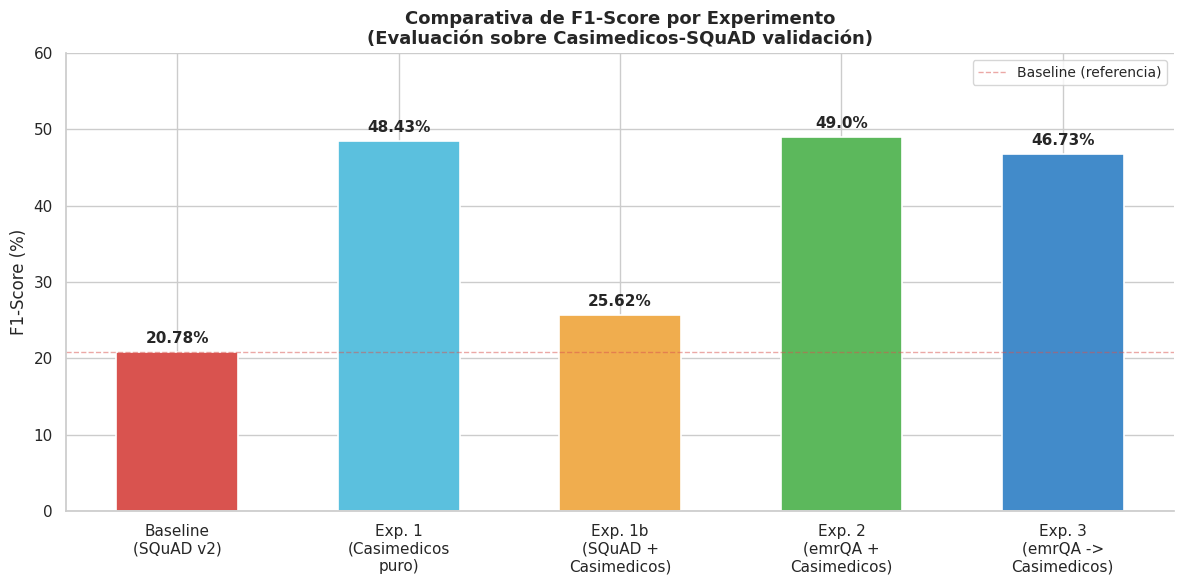

Gráfico guardado como 'comparativa_f1_experimentos.png'


In [ ]:
# Gráfico comparativo de F1-Score por experimento
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

experimentos = [
    "Baseline\n(SQuAD v2)",
    "Exp. 1\n(Casimedicos\npuro)",
    "Exp. 1b\n(SQuAD +\nCasimedicos)",
    "Exp. 2\n(emrQA +\nCasimedicos)",
    "Exp. 3\n(emrQA ->\nCasimedicos)"
]
f1_scores = [20.78, 48.43, 25.62, 49.0, 46.73]
colores = ['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c', '#428bca']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(experimentos, f1_scores, color=colores, edgecolor='white', linewidth=1.2, width=0.55)

# Etiquetas encima de cada barra
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(val) + '%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Comparativa de F1-Score por Experimento\n(Evaluación sobre Casimedicos-SQuAD validación)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 60)
ax.axhline(y=20.78, color='#d9534f', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (referencia)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparativa_f1_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'comparativa_f1_experimentos.png'")